In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x1, x2, x3):
    return x1**2 + 8*x1 + 5*x2**2 + 7*x3**2 + 119.0*x3 + 531.75

def h_j(x_start, alpha=1.0, gamma=0.5, epsilon=0.001, max_iter=1000):
    x = np.array(x_start, dtype=float)
    n = len(x)
    pattern = np.eye(n)
    
    x_history = [x.copy()]
    f_history = [f(*x)]
    
    iter_count = 0
    
    while alpha > epsilon and iter_count < max_iter:
        iter_count += 1
        improved = False
        x_old = x.copy()
        
        for i in range(n):
            for direction in [1, -1]:
                x_new = x.copy()
                x_new[i] += direction * alpha
                if f(*x_new) < f(*x):
                    x = x_new
                    improved = True
                    break
        
        if improved:
            while True:
                x_pattern = 2*x - x_old
                if f(*x_pattern) < f(*x):
                    x_old = x.copy()
                    x = x_pattern.copy()
                else:
                    break
        
        x_history.append(x.copy())
        f_history.append(f(*x))
        
        if not improved:
            alpha *= gamma
    
    print('Количество итераций:', iter_count)
    return f(*x), x[0], x[1], x[2], x_history

x1_start = 8
x2_start = -2
x3_start = 6
epsilon = 0.01

f_min, x1_end, x2_end, x3_end, x_way = h_j([x1_start, x2_start, x3_start], epsilon=epsilon)

print('Минимум функции:', f_min)
print('Координаты минимума:', (x1_end, x2_end, x3_end))


Количество итераций: 12
Минимум функции: 10.0
Координаты минимума: (-4.0, 0.0, -8.5)


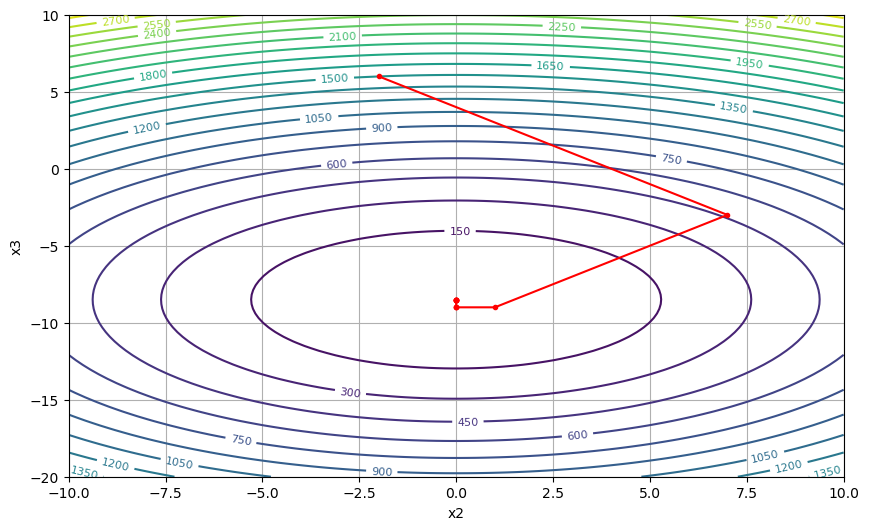

In [2]:
x1_vals = np.linspace(-10, 10, 100)
x2_vals = np.linspace(-20, 10, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(x1_end, X1, X2)

path_x2 = [point[1] for point in x_way]
path_x3 = [point[2] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x2, path_x3, 'r.-')

plt.xlabel('x2')
plt.ylabel('x3')

plt.grid()
plt.show()

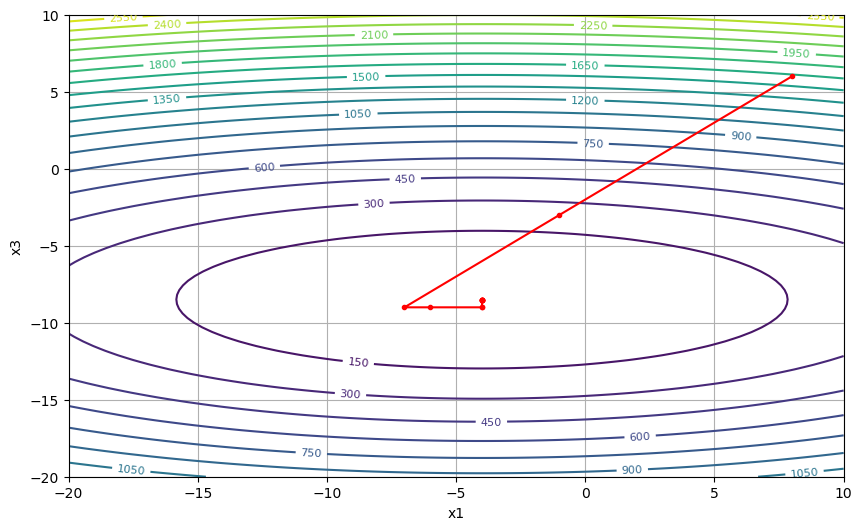

In [3]:
x1_vals = np.linspace(-20, 10, 100)
x2_vals = np.linspace(-20, 10, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, x2_end, X2)

path_x1 = [point[0] for point in x_way]
path_x3 = [point[2] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x1, path_x3, 'r.-')

plt.xlabel('x1')
plt.ylabel('x3')

plt.grid()
plt.show()

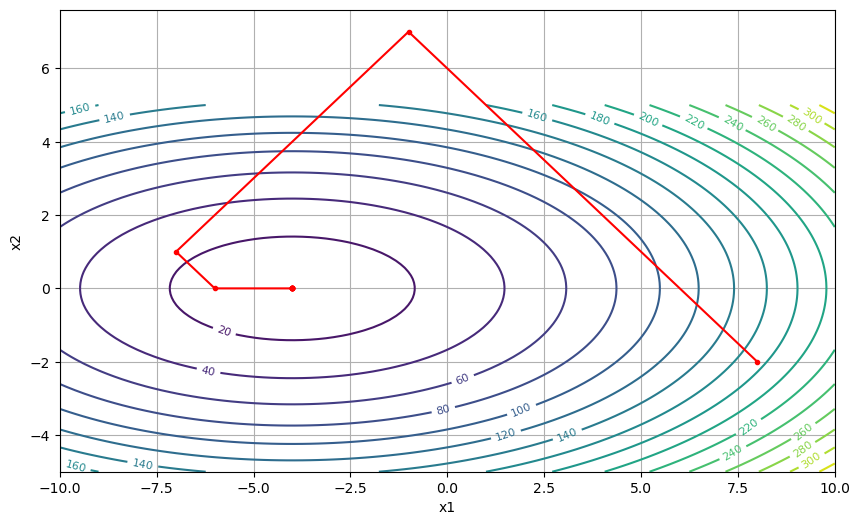

In [4]:
x1_vals = np.linspace(-10, 10, 100)
x2_vals = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z = f(X1, X2, x3_end)

path_x1 = [point[0] for point in x_way]
path_x2 = [point[1] for point in x_way]

plt.figure(figsize=(10, 6))
contour = plt.contour(X1, X2, Z, levels=20, cmap='viridis')
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(path_x1, path_x2, 'r.-')

plt.xlabel('x1')
plt.ylabel('x2')

plt.grid()
plt.show()